try to reproduce this one  
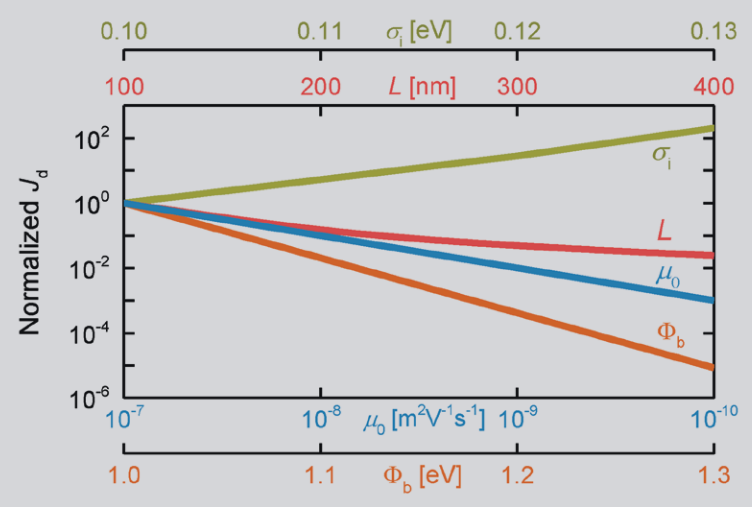

$$
J_d
=AqN_t\exp\left[-\frac{\Phi_b-\left(\dfrac{\sigma_i^2}{2k_B T}\right)-\Delta\Phi_b}{k_B T}\right]\cdot\mu_0^{*}
\exp\left[-C_i\left(\dfrac{\sigma_b}{k_B T}\right)^2\right]\cdot\frac{V}{L} $$
$$ 
=AqN_te^{\left[-\frac{\Phi_{inj}}{k_B T}\right]}\cdot\mu_0^{*}
e^{\left[-C_i\left(\dfrac{\sigma_b}{k_B T}\right)^2\right]}\cdot\frac{V}{L}

$$

$\Phi_b=1.0 eV$  
$μ_0=10^{-7} m^2V^{-1}s^{-1}$  
$L=100nm$  
$\sigma_i=0.10eV$

In [15]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants
from mpl_toolkits.mplot3d.axes3d import Axes3D # 3D 
from matplotlib import markers
import matplotlib.ticker as ticker
q = 1.602176634e-19
eps0 = 8.854187817e-12
kB_eV = 8.617333262e-5
T = 300
V = 2
eps_r = 3.5
eps = eps_r * eps0
Phi_b = 1.0
sigma_i = 0.10

## 1. consider different $L$

as $\Delta\Phi_b=\sqrt{\frac{qE}{4\piε}}$  
and $E=\frac{V}{L}$  
--> $\Delta\Phi_b∝\sqrt{\frac{V}{L}}$  

plug in $J_d$:
we have$$J_d ∝ \frac{1}{L}\exp{(C\sqrt{\frac{V}{L}})}$$


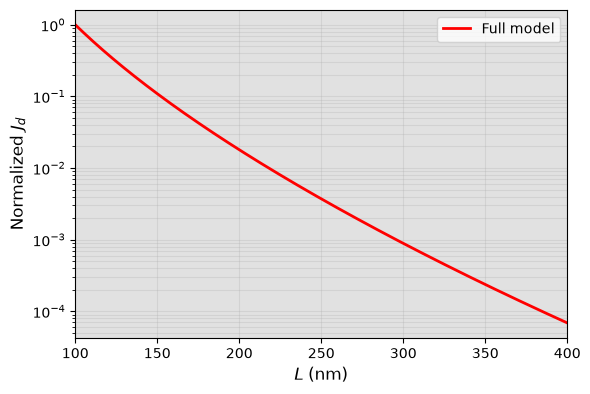

In [24]:
L_nm = np.linspace(100, 400, 300)
L = L_nm * 1e-9

arg = -(
    Phi_b
    - sigma_i**2 / (2 * kB_eV * T)
    - np.sqrt(q * V / L / (4 * np.pi * eps))
) / (kB_eV * T)
J = (V / L) * np.exp(arg)
J_normalized = J / J[0]

fig = plt.figure(figsize=(6, 4), facecolor="white")
ax = fig.add_axes((0.12, 0.12, 0.82, 0.82),
                  facecolor="#e1e1e1")

ax.plot(
    L_nm,
    J_normalized,
    color="red",
    linewidth=2,
    label=r"Full model"
)

ax.set_yscale("log")
ax.set_xlabel(r"$L\;(\mathrm{nm})$", fontsize=12)
ax.set_ylabel(r"Normalized $J_d$", fontsize=12)

ax.set_xlim(100, 400)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.show()

## 2. $μ_0$

easy to find that it linear positive correlation
$$J_d∝μ_0$$

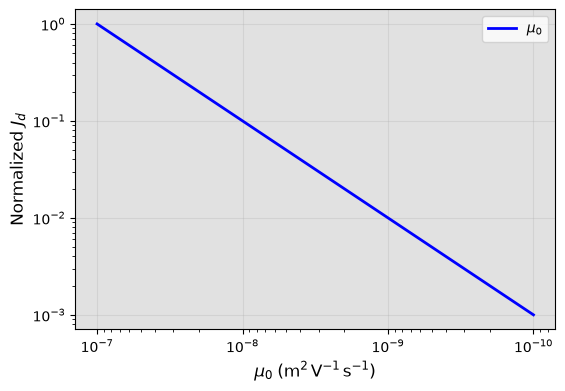

In [19]:
mu0 = np.logspace(-7, -10, 300)

J = mu0.copy()

J /= J[0]

fig = plt.figure(figsize=(6,4), facecolor="white")
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
ax = fig.add_axes((left, bottom, width, height),
                  facecolor="#e1e1e1")

ax.plot(mu0,
        J,
        color="blue",
        linewidth=2,
        label=r"$\mu_0$")

ax.set_xscale("log")
ax.set_yscale("log")

ax.invert_xaxis()

ax.set_xlabel(
    r"$\mu_0\;(\mathrm{m^2\,V^{-1}\,s^{-1}})$",
    fontsize=12
)
ax.set_ylabel(r"Normalized $J_d$", fontsize=12)

ax.legend()
ax.grid(alpha=0.3)

## 3. $\sigma_i$


$$J_d ∝ \exp{\left[\frac{\sigma_i^2}{2({k_BT})^2}\right]}$$

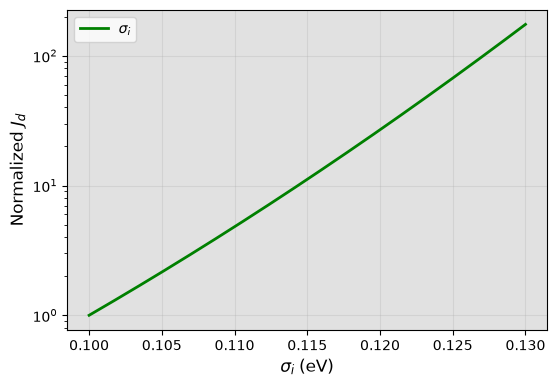

In [20]:
sigma_i = np.linspace(0.10, 0.13, 300)

DeltaPhi = 0.18  # eV，固定值（保持其它参数不变）

arg = -(
    Phi_b
    - sigma_i**2 / (2 * kBT_eV)
    - DeltaPhi
) / kBT_eV

J = np.exp(arg)

J /= J[0]

fig = plt.figure(figsize=(6,4), facecolor="white")
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
ax = fig.add_axes((left, bottom, width, height),
                  facecolor="#e1e1e1")

ax.plot(
    sigma_i,
    J,
    color="green",
    linewidth=2,
    label=r"$\sigma_i$"
)

ax.set_yscale("log")

ax.set_xlabel(r"$\sigma_i\;(\mathrm{eV})$", fontsize=12)
ax.set_ylabel(r"Normalized $J_d$", fontsize=12)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

## 4. $\Phi_b$

$$J_d ∝ \exp{\left[\frac{\Phi_b}{{k_BT}}\right]}$$

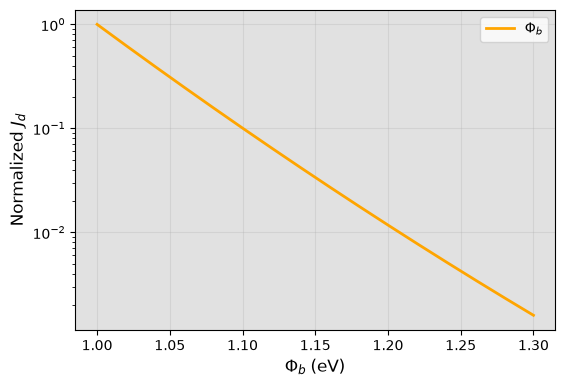

In [23]:
Phi_b = np.linspace(1.0, 1.3, 300)


arg = -(
    Phi_b
    - sigma_i**2 / (2 * kBT_eV)
    - DeltaPhi
) / kBT_eV

J = np.exp(arg)
J /= J[0]

fig = plt.figure(figsize=(6,4), facecolor="white")
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
ax = fig.add_axes((left, bottom, width, height),
                  facecolor="#e1e1e1")

ax.plot(
    Phi_b,
    J,
    color="orange",
    linewidth=2,
    label=r"$\Phi_b$"
)

ax.set_yscale("log")

ax.set_xlabel(r"$\Phi_b\;(\mathrm{eV})$", fontsize=12)
ax.set_ylabel(r"Normalized $J_d$", fontsize=12)

ax.legend()
ax.grid(alpha=0.3)